In [1]:
from ta.volatility import AverageTrueRange

import pandas as pd
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from datetime import datetime
import numpy as np

import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

from backtesting import Strategy
from backtesting import Backtest


from datetime import timedelta
import Util

from enum import Enum

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\_plotting.py:55: UserWarning: Jupyter Notebook detected. Setting Bokeh output to notebook. This may not work in Jupyter clients without JavaScript support, such as old IDEs. Reset with `backtesting.set_bokeh_output(notebook=False)`.
  warnings.warn('Jupyter Notebook detected. '


Loading BokehJS ...

In [2]:
class KeyLevel(Enum):
    SUPPORT = 1
    RESISTANT = 2

In [3]:
pair = 'GBPJPY'

df_d1_raw = pd.read_csv(f"../Trading Data/{pair}_D1.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_h4_raw = pd.read_csv(f"../Trading Data/{pair}_H4.csv",sep=',', parse_dates=['Date'], index_col='Date')
df_m15_raw = pd.read_csv(f"../Trading Data/{pair}_M15.csv",sep=',', parse_dates=['Date'], index_col='Date')

print(df_d1_raw)
print(df_h4_raw)
print(df_m15_raw)

               Open     High      Low    Close  Tickvol
Date                                                   
2010-09-10  129.605  130.065  128.995  129.255   172229
2010-09-13  129.565  130.115  128.780  129.090   215859
2010-09-14  129.105  129.430  127.640  129.015   226170
2010-09-15  129.015  134.070  128.555  133.975   252317
2010-09-16  133.975  134.260  132.970  134.150   222443
...             ...      ...      ...      ...      ...
2026-09-18  208.323  211.276  208.233  210.095   364707
2026-09-21  210.296  210.762  209.676  210.321   243731
2026-09-22  210.321  210.892  209.513  210.080   333200
2026-09-23  210.080  210.176  209.422  209.564   273936
2026-09-24  209.566  210.105  208.768  209.848   199988

[4183 rows x 5 columns]
                        Open     High      Low    Close  Tickvol
Date                                                            
2010-09-10 04:00:00  129.605  129.630  128.995  129.385    25539
2010-09-10 08:00:00  129.380  129.985  129.275  129.

In [4]:
structure_d1_window = 2
structure_m15_window = 2

date_format = '%Y-%m-%d %H:%M'
# start_date = '2023-1-1 00:00'
# end_date = '2024-3-29 00:00'
start_date = datetime.strptime('2021-1-1 00:00', date_format)
end_date = datetime.strptime('2026-9-16 00:00', date_format)
# start_date = '2022-01-1 00:00'
# end_date = '2026-9-16 00:00'

timezone = "Europe/London"

# nombre de jours pour les high.low
define_key_level_window = 15

# window for look back for key level
back_candles_window = 20

# gap t avoid look ahead
gap_look_ahead = 1

# nombre de candle au dessus/ en desous de key level après breakout
breakout_candles = 9

# nombre de jours à chercher key level
key_level_lookback_days = 25

# vérifier si 30 candle dans ke passé pour valider un valid breakout,
# un valid breakout doit avoir {breakout_candles} candles au dessus du resistant level
breakout_candles_lookback = 30

start_trade_hour = 9
stop_trade_hour = 19

In [5]:
# process D1 data
df_d1 = df_d1_raw.loc[start_date - timedelta(days=30) : end_date]

df_d1 = Util.implement_market_structure_states_direct(df_d1, n=structure_d1_window)
df_d1["state_changed"] = df_d1["market_state"] != df_d1[
    "market_state"
].shift(1)
print(df_d1[df_d1["state_changed"]][["Close", "market_state"]])
df_d1 = df_d1.loc[start_date : end_date]

              Close market_state
Date                            
2020-12-02  139.632          NaN
2020-12-03  139.680          NaN
2020-12-04  139.937          NaN
2020-12-07  139.114          NaN
2020-12-08  139.134          NaN
...             ...          ...
2026-03-30  210.598      BEARISH
2026-04-09  213.599      BULLISH
2026-04-30  213.107      BEARISH
2026-05-25  214.592      BULLISH
2026-07-30  215.005      BEARISH

[76 rows x 2 columns]


In [6]:
# process h4 data
df_h4 = df_h4_raw.loc[start_date - timedelta(days=20) : end_date]
df_h4 = Util.implement_market_structure_states_direct(df_h4, 5)
df_h4 = df_h4.loc[start_date : end_date]

h4_d1_direction_list = []
for i in range(len(df_d1)):
    row = df_d1.iloc[i]
    start_date_daily = row.name
    end_date_daily = start_date_daily + timedelta(hours=23, minutes=59)
    df_by_day = df_h4.loc[f'{start_date_daily}' : f'{end_date_daily}']

    for index2, row2 in df_by_day.iterrows():
        h4_d1_direction_list.append(df_d1.iloc[i-1]['market_state'])

df_h4['market_state_d1'] = h4_d1_direction_list

indicator_atr_14 = AverageTrueRange(df_h4['High'], df_h4['Low'], df_h4['Close'], window=14)
df_h4['ATR'] = indicator_atr_14._atr

df_h4

,Open,High,Low,Close,Tickvol,is_swing_high,is_swing_low,market_state,market_state_d1,ATR
Date,,,,,,,,,,
2021-01-04 00:00:00,140.944,141.304,140.776,141.005,37352,True,False,BULLISH,BEARISH,0.000000
2021-01-04 04:00:00,141.007,141.043,140.847,140.938,20550,False,False,BULLISH,BEARISH,0.000000
2021-01-04 08:00:00,140.936,141.064,140.412,140.757,47343,False,False,BULLISH,BEARISH,0.000000
2021-01-04 12:00:00,140.758,140.861,140.188,140.226,55445,False,False,BULLISH,BEARISH,0.000000
2021-01-04 16:00:00,140.227,140.233,139.687,139.870,55631,False,False,BULLISH,BEARISH,0.000000
...,...,...,...,...,...,...,...,...,...,...
2026-09-15 08:00:00,208.652,209.090,208.514,208.655,56407,False,False,BEARISH,BEARISH,0.567701
2026-09-15 12:00:00,208.655,209.211,208.607,209.168,74480,False,False,BULLISH,BEARISH,0.570294
2026-09-15 16:00:00,209.167,209.224,208.885,209.066,38410,False,False,BULLISH,BEARISH,0.553773


In [7]:
resistants_list = Util.define_resistant_level_with_atr(df_h4, define_key_level_window, atr_multiplier=0.7, min_touched=3)

supports_list = Util.define_support_level_with_atr(df_h4, define_key_level_window, atr_multiplier=0.7, min_touched=3)

supports_list
resistants_list

[[(Timestamp('2021-04-16 04:00:00'),
   Open               149.823
   High               149.839
   Low                149.381
   Close              149.445
   Tickvol              16885
   is_swing_high        False
   is_swing_low          True
   market_state       BEARISH
   market_state_d1    BULLISH
   ATR                0.36659
   Name: 2021-04-16 04:00:00, dtype: object),
  149.516],
 [(Timestamp('2021-05-19 12:00:00'),
   Open                154.688
   High                154.723
   Low                 153.536
   Close               153.608
   Tickvol               60050
   is_swing_high         False
   is_swing_low           True
   market_state        BEARISH
   market_state_d1     BULLISH
   ATR                0.369039
   Name: 2021-05-19 12:00:00, dtype: object),
  153.576],
 [(Timestamp('2021-05-26 00:00:00'),
   Open                153.919
   High                153.971
   Low                  153.77
   Close               153.971
   Tickvol               17654
   is_sw

In [8]:
df_h4['support_point'] = df_h4.apply(lambda row: Util.support_pos(supports_list, row), axis=1)
df_h4['is_support'] = df_h4.apply(lambda row: Util.is_support(supports_list, row), axis=1)

df_h4['resistant_point'] = df_h4.apply(lambda row: Util.resistant_pos(resistants_list, row), axis=1)
df_h4['is_resistant'] = df_h4.apply(lambda row: Util.is_resistant(resistants_list, row), axis=1)

In [9]:
df_h4['valid_breakout_support_levels'] = Util.is_candles_above_support_level_list(df_h4, breakout_candles, key_level_lookback_days)

df_h4['valid_breakout_resistant_levels'] = Util.is_candles_below_resistant_level_list(df_h4, breakout_candles, key_level_lookback_days)

In [10]:
# process m15 data
df_m15 = df_m15_raw.loc[start_date - timedelta(hours=3): end_date]
df_m15 = Util.implement_market_structure_states_direct(df_m15, n=structure_m15_window)

m15_daily_direction_list = []

m15_h4_resistant_level_list = []
m15_is_resistants_list = []
m15_is_below_resistant_list = []

m15_h4_support_level_list = []
m15_is_supports_list = []
m15_is_above_support_list = []

index_list = []

df_m15 = df_m15.loc[start_date : end_date]
for i in range(len(df_h4)):
    row = df_h4.iloc[i]
    start_date_h4 = row.name
    end_date_h4 = start_date_h4 + timedelta(hours=3, minutes=59)
    df_by_day = df_m15.loc[f'{start_date_h4}' : f'{end_date_h4}']

    for index2, row2 in df_by_day.iterrows():
        m15_daily_direction_list.append(df_h4.iloc[i]['market_state_d1'])

        m15_h4_resistant_level_list.append(df_h4.iloc[i]['resistant_point'])
        m15_is_resistants_list.append(df_h4.iloc[i]['is_resistant'])
        m15_is_below_resistant_list.append(df_h4.iloc[i]['valid_breakout_resistant_levels'])
        # affect current market states of H4 candle because the result is market state of previous D1 candle

        m15_h4_support_level_list.append(df_h4.iloc[i]['support_point'])
        m15_is_supports_list.append(df_h4.iloc[i]['is_support'])
        m15_is_above_support_list.append(df_h4.iloc[i]['valid_breakout_support_levels'])

        # ajust to daylight saving time
        dst = pd.Timestamp(index2, tz=timezone).dst()
        if dst == timedelta(0):
            index2 = index2 - timedelta(hours=1)
            index_list.append(index2)
        else:
            index_list.append(index2)

df_m15['market_state_d1'] = m15_daily_direction_list

df_m15['resistant_point'] = m15_h4_resistant_level_list
df_m15['is_resistant'] = m15_is_resistants_list
df_m15['valid_breakout_resistant_levels'] = m15_is_below_resistant_list

df_m15['support_point'] = m15_h4_support_level_list
df_m15['is_support'] = m15_is_supports_list
df_m15['valid_breakout_support_levels'] = m15_is_above_support_list

df_m15.index = index_list

df_m15

,Open,High,Low,Close,Tickvol,is_swing_high,is_swing_low,market_state,market_state_d1,resistant_point,is_resistant,valid_breakout_resistant_levels,support_point,is_support,valid_breakout_support_levels
2021-01-03 23:00:00,140.944,141.110,140.944,141.100,2767,False,True,NaN,BEARISH,NaN,False,[],NaN,False,[]
2021-01-03 23:15:00,141.099,141.204,141.070,141.186,1223,False,False,NaN,BEARISH,NaN,False,[],NaN,False,[]
2021-01-03 23:30:00,141.186,141.304,141.158,141.282,1042,True,False,NaN,BEARISH,NaN,False,[],NaN,False,[]
2021-01-03 23:45:00,141.278,141.301,141.218,141.244,1886,False,False,NaN,BEARISH,NaN,False,[],NaN,False,[]
2021-01-04 00:00:00,141.247,141.275,140.988,141.007,3577,False,False,NaN,BEARISH,NaN,False,[],NaN,False,[]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-09-15 23:00:00,208.895,209.029,208.895,209.018,1853,True,False,BEARISH,BEARISH,NaN,False,[],NaN,False,[]
2026-09-15 23:15:00,209.020,209.027,208.982,208.996,1268,False,False,BEARISH,BEARISH,NaN,False,[],NaN,False,[]
2026-09-15 23:30:00,208.997,209.013,208.926,208.953,1279,False,False,BEARISH,BEARISH,NaN,False,[],NaN,False,[]
2026-09-15 23:45:00,208.951,209.021,208.923,209.019,1261,False,False,BEARISH,BEARISH,NaN,False,[],NaN,False,[]


In [11]:
candle_index = datetime.strptime('2022-11-15 06:00', date_format)

print(Util.get_resistant_list(df_m15, candle_index, key_level_lookback_days, 1))
print(Util.get_support_list(df_m15, candle_index, key_level_lookback_days, 1))

resistant_point
165.019    165.019
165.036    165.036
Name: resistant_point, dtype: float64
support_point
169.78    169.78
Name: support_point, dtype: float64


In [12]:
# 2024-03-25 06:00:00 2300
print(Util.get_valid_breakout_support_level(df_m15, 2956, 30))
print(Util.get_valid_breakout_resistant_level(df_m15, 2956, 30))

[142.276, 142.273, 142.261]
[]


In [13]:
def is_existed(list, value):
    for i in range(len(list)):
        if list[i] == value:
            return True
    return False

In [14]:
# using m15 market structure for entry
def apply_total_signal(df, key_level_lookback_days = 20, gap=1, breakout_candles_lookback = 30, start_trade_hour=8, stop_trade_hour=19):
    # Initialize the 'TotalSignal' column
    df_signal_list = []
    valid_support_levels_list = []
    valid_resistant_levels_list = []
    current_day = None

    # short variables
    is_resistant_level_touched = False
    is_below_resistant_levels = False
    high_tf_condition_short_satisfied = False
    high_tf_condition_short_candle = None
    m15_market_state_bearish = False

    # long variables
    is_support_level_touched = False
    is_above_support_levels = False
    high_tf_condition_long_satisfied = False
    high_tf_condition_long_candle = None
    m15_market_state_bullish = False

    # we want market structure to switch from bearish to bullish when htf conditions are met
    # if market structure is already bullish we need to wait
    previous_market_structure = None

    resistants_levels_touched = []
    supports_levels_touched = []

    for i in range(0, len(df)):
        current_bar_date = df.index[i]
        signal = 0
        # valid resistants levels are when valid breakout and levels touched
        valid_resistant_levels = []
        valid_support_levels = []

        if current_day != current_bar_date.date() or current_bar_date.time().hour >= stop_trade_hour:
            current_day = current_bar_date.date()
            # short
            high_tf_condition_short_satisfied = False
            is_resistant_level_touched = False
            valid_breakout_resistant_levels = []
            resistants_levels_touched = []
            is_below_resistant_levels = False

            # long
            high_tf_condition_long_satisfied = False
            is_support_level_touched = False
            valid_breakout_support_levels = []
            supports_levels_touched = []
            is_above_support_levels = False

        # short
        # d1 trending conditions
        c_short_daily_direction = df['market_state_d1'].iloc[i-1] == 'BEARISH'
        if c_short_daily_direction:
            c_m15_ms_bearish = df['market_state'].iloc[i] == 'BEARISH'

            # h4 key level conditions
            resistants_levels = Util.get_resistant_list(df, current_bar_date, key_level_lookback_days, gap)
            for level in resistants_levels:
                if df['High'].iloc[i-1] > level:
                    is_resistant_level_touched = True
                    if not is_existed(resistants_levels_touched, level):
                        resistants_levels_touched.append(level)
            
            # Combine conditions
            if (is_resistant_level_touched and
                not high_tf_condition_short_satisfied):
                high_tf_condition_short_satisfied = True
                high_tf_condition_short_candle = current_bar_date
                previous_market_structure = df['market_state'].iloc[i]
                print(f"{current_bar_date} {i}")

            if (high_tf_condition_short_satisfied == True and
                c_m15_ms_bearish and
                high_tf_condition_short_candle < current_bar_date and
                previous_market_structure == 'BULLISH'):
                m15_market_state_bearish = True

            # breakout_candles_below candle needs to be below resistant level for the breakout to be valid
            valid_breakout_resistant_levels = Util.get_valid_breakout_resistant_level(df, i, breakout_candles_lookback)
            
            for valid_level in valid_breakout_resistant_levels:
                for level_touched in resistants_levels_touched:
                    if valid_level == level_touched:
                        valid_resistant_levels.append(valid_level)
                        is_below_resistant_levels = True

            c_time_trade = start_trade_hour <= current_bar_date.hour and current_bar_date.hour <= stop_trade_hour
            if c_time_trade:
                if (high_tf_condition_short_satisfied == True and
                    m15_market_state_bearish and
                    is_below_resistant_levels):
                    signal = 1

        # long
        c_long_daily_direction = df['market_state_d1'].iloc[i-1] == 'BULLISH'
        if c_long_daily_direction:
            c_m15_ms_bullish = df['market_state'].iloc[i] == 'BULLISH'
            
            # h4 support level conditions
            supports_levels = Util.get_support_list(df, current_bar_date, key_level_lookback_days, gap)
            for level in supports_levels:
                if df['Low'].iloc[i-1] < level:
                    is_support_level_touched = True
                    if not is_existed(supports_levels_touched, level):
                        supports_levels_touched.append(level)

            # Combine conditions
            if (is_support_level_touched and
                not high_tf_condition_long_satisfied):
                high_tf_condition_long_satisfied = True
                m15_market_state_bullish = False
                high_tf_condition_long_candle = current_bar_date
                previous_market_structure = df['market_state'].iloc[i]
                # print(f"high_tf_condition_long_satisfied {current_bar_date} {i}")
    
            if (high_tf_condition_long_satisfied and
                c_m15_ms_bullish and
                high_tf_condition_long_candle < current_bar_date and
                previous_market_structure == 'BEARISH'):
                # print(f"m15_market_state_bullish {current_bar_date} {i}")
                m15_market_state_bullish = True

            # breakout_candles_above candle needs to be above support level for the breakout to be valid
            valid_breakout_support_levels = Util.get_valid_breakout_support_level(df, i, breakout_candles_lookback)
            for valid_level in valid_breakout_support_levels:
                for level_touched in supports_levels_touched:
                    if valid_level == level_touched:
                        valid_support_levels.append(valid_level)
                        is_above_support_levels = True

            c_time_trade = start_trade_hour <= current_bar_date.hour and current_bar_date.hour <= stop_trade_hour
            if c_time_trade:
                if (high_tf_condition_long_satisfied == True and
                    m15_market_state_bullish and
                    is_above_support_levels):
                    print(f"signal {current_bar_date} {i}")
                    signal = 2

        if previous_market_structure != df['market_state'].iloc[i]:
            if df['market_state'].iloc[i] == 'BULLISH':
                m15_market_state_bearish = False
            if df['market_state'].iloc[i] == 'BEARISH':
                m15_market_state_bullish = False
            previous_market_structure = df['market_state'].iloc[i]    

        df_signal_list.append(signal)
        valid_resistant_levels_list.append(valid_resistant_levels)
        valid_support_levels_list.append(valid_support_levels)

    return df_signal_list, valid_resistant_levels_list, valid_support_levels_list

df_m15['TotalSignal'], df_m15['valid_resistant_levels'], df_m15['valid_support_levels'] = apply_total_signal(df=df_m15, key_level_lookback_days=key_level_lookback_days, gap=gap_look_ahead,
                                                                             breakout_candles_lookback=breakout_candles_lookback, start_trade_hour=start_trade_hour, stop_trade_hour=stop_trade_hour)

signal 2021-06-07 12:00:00 10472
signal 2021-06-07 12:15:00 10473
signal 2021-06-07 12:30:00 10474
signal 2021-06-07 12:45:00 10475
signal 2021-06-07 13:00:00 10476
signal 2021-06-07 13:15:00 10477
signal 2021-06-07 13:30:00 10478
signal 2021-06-07 13:45:00 10479
signal 2021-06-07 14:00:00 10480
signal 2021-06-07 14:15:00 10481
signal 2021-06-07 17:00:00 10492
signal 2021-06-07 17:15:00 10493
signal 2021-06-07 17:30:00 10494
signal 2021-06-07 17:45:00 10495
signal 2021-06-07 18:00:00 10496
signal 2021-06-07 18:15:00 10497
signal 2021-06-07 18:30:00 10498
signal 2021-06-07 18:45:00 10499
signal 2021-06-08 15:45:00 10583
signal 2021-06-08 16:00:00 10584
signal 2021-06-08 16:15:00 10585
signal 2021-06-08 16:30:00 10586
signal 2021-06-08 16:45:00 10587
signal 2021-06-08 17:00:00 10588
signal 2021-06-08 17:15:00 10589
signal 2021-06-08 17:30:00 10590
signal 2021-06-08 17:45:00 10591
signal 2021-06-08 18:00:00 10592
signal 2021-06-08 18:15:00 10593
signal 2021-06-08 18:30:00 10594
signal 202

In [15]:
len(df_m15[df_m15.TotalSignal != 0])

2527

In [16]:
# add some sl tp management
def SIGNAL():
    return dfopt.TotalSignal

class MyStrat(Strategy):
    mysize = 0.5
    slcoef = 2
    TPcoef = 2
    risk_percent = 0.01
    last_swing_low = None
    last_swing_high = None
    previous_swing_low = None
    previous_swing_high = None
    breakout_candles_lookback = 0
    key_level_gap = 0.2
    last_trade_index = 0

    stoploss_info_list = []
    valid_resistant_level = None
    valid_support_level = None
    
    def init(self):
        self.current_day = None
        self.order_placed_time = None
        self.setup_duration = None
        
        self.stoploss_info_list = []
        self.valid_resistant_level = None
        self.valid_support_level = None

        super().init()
        self.breakout_candles_lookback = breakout_candles_lookback
        self.signal1 = self.I(SIGNAL)


    def reset_order(self):
        # delete placed order at the end of the day if not executed
        if self.order_placed_time:
            for order in self.orders:
                order_executed= False
                for trade in self.trades:
                    if trade.tag == order.tag:
                        order_executed = True

                if order_executed == False:
                    order.cancel()

        self.order_placed_time = None
        self.setup_duration = None
        self.valid_resistant_level = None
        self.valid_support_level = None

    def get_highest_high(self):
        return self.data.High[len(self.data.High) - 100 : len(self.data.High)].max()

    def get_lowest_low(self):
        return self.data.Low[len(self.data.Low) - 100 : len(self.data.Low)].min()

    def is_entry_in_valid_short_zone(self, valid_resistant_list):
        return self.data.Close[-1] < max(valid_resistant_list) + self.key_level_gap

    def is_entry_in_valid_long_zone(self, valid_support_list):
        return self.data.Close[-1] > min(valid_support_list) - self.key_level_gap

    def add_stoploss_info_list(self, info):
        is_added = False
        for stoploss_info in self.stoploss_info_list:
            if stoploss_info[0] == info[0] and stoploss_info[1] == info[1]:
                is_added = True
                stoploss_info[2] = info[2]

        if is_added == False:
            self.stoploss_info_list.append(info)

    def get_stoploss_info(self, key_level_type, key_level_value):
        for stoploss_info in self.stoploss_info_list:
            if stoploss_info[0] == key_level_type and stoploss_info[1] == key_level_value:
                return stoploss_info
        return None

    def dynamic_stoploss(self):
        # delete placed order at the end of the day if not executed
        if self.order_placed_time:
            for order in self.orders:
                order_executed= False
                for trade in self.trades:
                    if trade.tag == order.tag:
                        order_executed = True
                        if order.stop is not None:
                            # in long trade, short order is for sl and inverse for short trade
                            # so we identify short order for long trade to identify sl
                            if order.is_short:
                                self.add_stoploss_info_list([KeyLevel.SUPPORT, self.valid_support_level, order.stop])
                            else:
                                self.add_stoploss_info_list([KeyLevel.RESISTANT, self.valid_resistant_level, order.stop])


                if order_executed == False:
                    order.cancel()
                    if order.is_short:
                        sl = abs(order.stop - self.get_highest_high())
                        tp = order.stop - self.TPcoef * sl
                        position_size = int((self.risk_percent * self.equity) / sl)
                        self.sell(sl = self.get_highest_high(), tp = tp, size=position_size, stop=order.stop)
                    else:
                        sl = abs(order.stop - self.get_lowest_low())
                        tp = order.stop + self.TPcoef * sl
                        position_size = int((self.risk_percent * self.equity) / sl)
                        order = self.buy(sl = self.get_lowest_low(), tp = tp, size=position_size, stop=order.stop)

    def get_tag(self):
        return f"{self.order_placed_time}"

    def wait_3_candles_before_new_trade(self):
        return self.last_trade_index + 3
    
    def next(self):
        super().next()
        index = len(self.data.index)

        # when an order is placed, it will be valable for 12h
        if self.setup_duration is not None and index >= self.setup_duration:
            self.reset_order()

        # place sl to the lowest/highest
        self.dynamic_stoploss()

        if len(self.trades) > 0:
            self.last_trade_index = index

        if len(self.orders)==0 and index >= self.wait_3_candles_before_new_trade():
            if self.signal1[-1]==1:
                valid_resistant_list = Util.get_valid_resistant_level(dfopt, index, breakout_candles_lookback)
                if len(valid_resistant_list) > 0:
                    valid_resistant_level = max(valid_resistant_list)
                    is_entry_in_valid_zone = self.is_entry_in_valid_short_zone(valid_resistant_list)
                    planned_entry_price = 0
                    sl = 0

                    if is_entry_in_valid_zone: 
                        planned_entry_price = self.data.Close[-1]
                        sl = abs(planned_entry_price - self.get_highest_high())
                    else :
                        planned_entry_price = valid_resistant_level + self.key_level_gap
                        sl = abs(planned_entry_price - self.get_highest_high())
    
                    sl1 = planned_entry_price + sl
                    stoploss_info = self.get_stoploss_info(KeyLevel.RESISTANT, valid_resistant_level)
                    if stoploss_info is None or sl1 > stoploss_info[2]:
                        tp = self.TPcoef * sl
                        position_size = int((self.risk_percent * self.equity) / sl)
                        tp1 = planned_entry_price - tp

                        self.valid_resistant_level = valid_resistant_level
                        self.setup_duration = len(self.data.index) + 50
                        self.order_placed_time = self.data.index[-1]

                        if is_entry_in_valid_zone: 
                            self.sell(sl=sl1, tp=tp1, size=position_size, tag=self.get_tag())
                            # print(f"short {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & valid_resistant_level = {valid_resistant_level} & entry_price = {planned_entry_price}")
                        else:
                            self.sell(sl=sl1, tp=tp1, size=position_size, stop=planned_entry_price, tag=self.get_tag())
                            # print(f"short {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & valid_resistant_level = {valid_resistant_level} & planned_entry_price = {planned_entry_price}")

            if self.signal1[-1]==2:
                valid_support_list = Util.get_valid_support_level(dfopt, index, breakout_candles_lookback)
                if len(valid_support_list) > 0:
                    valid_support_level = min(valid_support_list)
                    is_entry_in_valid_zone = self.is_entry_in_valid_long_zone(valid_support_list)
                    planned_entry_price = 0
                    sl = 0
                    
                    if is_entry_in_valid_zone: 
                        planned_entry_price = self.data.Close[-1]
                        sl = abs(planned_entry_price - self.get_lowest_low())
                    else :
                        planned_entry_price = valid_support_level - self.key_level_gap
                        sl = abs(planned_entry_price - self.get_lowest_low())

                    sl1 = planned_entry_price - sl
                    stoploss_info = self.get_stoploss_info(KeyLevel.SUPPORT, valid_support_level)
                    # print(f"{stoploss_info} {valid_support_level}")
                    if stoploss_info is None or sl1 < stoploss_info[2]:
                        tp = self.TPcoef * sl
                        position_size = int((self.risk_percent * self.equity) / sl)
                        tp1 = planned_entry_price + tp

                        self.valid_support_level = valid_support_level
                        self.setup_duration = len(self.data.index) + 50
                        self.order_placed_time = self.data.index[-1]

                        if is_entry_in_valid_zone: 
                            self.buy(sl=sl1, tp=tp1, size=position_size, tag=self.get_tag())
                            # print(f"long {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & valid_support_level = {valid_support_level} & entry_price = {planned_entry_price}")
                        else:
                            self.buy(sl=sl1, tp=tp1, size=position_size, stop=planned_entry_price, tag=self.get_tag())
                            # print(f"long {self.data.index[-1]} sl = {sl1} & sgnal = {self.signal1[-1]} & valid_support_level = {valid_support_level} & planned_entry_price = {planned_entry_price}")
                            

In [17]:
start_date_chart = '2021-1-1 00:00'
end_date_chart = '2026-9-30 00:00'
dfopt = df_m15.loc[start_date_chart : end_date_chart]
# dfopt = df_m15

In [18]:
# bt = Backtest(dfopt, MyStrat, cash=10000, margin=0.02, commission=0.0002)
bt = Backtest(dfopt, MyStrat, cash=10000, margin=0.02) #0.0002
stats = bt.run()

print(stats)

bt.plot()

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\backtesting.py:1009: UserWarning: time=63657: Broker canceled the order due to insufficient margin (equity=10899.95, margin_available=10899.95).
  warnings.warn(


Start                     2021-01-03 23:00:00
End                       2026-09-16 00:00:00
Duration                   2081 days 01:00:00
Exposure Time [%]                     6.91715
Equity Final [$]                    13246.838
Equity Peak [$]                     13271.018
Return [%]                           32.46838
Buy & Hold Return [%]                48.17505
Return (Ann.) [%]                     4.51359
Volatility (Ann.) [%]                 4.66287
CAGR [%]                              5.05876
Sharpe Ratio                          0.96799
Sortino Ratio                         1.77025
Calmar Ratio                          0.74573
Alpha [%]                            31.51182
Beta                                  0.01986
Max. Drawdown [%]                    -6.05262
Avg. Drawdown [%]                    -0.47774
Max. Drawdown Duration      361 days 12:30:00
Avg. Drawdown Duration        8 days 20:40:00
# Trades                                   62
Win Rate [%]                      

c:\Users\kyanh\AppData\Local\Programs\Python\Python313-arm64\Lib\site-packages\backtesting\_plotting.py:141: UserWarning: Data contains too many candlesticks to plot; downsampling to '8h'. See `Backtest.plot(resample=...)`
  warnings.warn(f"Data contains too many candlesticks to plot; downsampling to {freq!r}. "


GridPlot(id='p1308', ...)

In [19]:
df_m15['pointpos'] = df_m15.apply(lambda row: Util.pointpos(row), axis=1)

In [20]:
start_date_chart = '2021-6-1 00:00'
end_date_chart = '2021-6-30 00:00'
dfpl = df_m15.loc[start_date_chart : end_date_chart]#.set_index("Gmt time")

# Create a plot with 2 rows
fig = make_subplots(rows=1, cols=1)

# Add candlestick plot on the first row
fig.add_trace(go.Candlestick(x=dfpl.index,
                             open=dfpl['Open'],
                             high=dfpl['High'],
                             low=dfpl['Low'],
                             close=dfpl['Close']),
              row=1, col=1)

#Add markers for trade entry points on the same subplot
# fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['support_point'], mode="markers",
#                          marker=dict(size=8, color="green"),
#                          name="support point"),
#               row=1, col=1)

# Add markers for entry point m15
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['pointpos'], mode="markers",
                         marker=dict(size=12, color="MediumPurple"),
                         name="entry"),
              row=1, col=1)

# # Add markers for market structure daily = bullish
# fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['mk_bullish_pos'], mode="markers",
#                          marker=dict(size=8, color="green"),
#                          name="bullish"),
#               row=1, col=1)

# # Add markers for market structure daily = bearish
# fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['mk_bearish_pos'], mode="markers",
#                          marker=dict(size=8, color="red"),
#                          name="bearish"),
#               row=1, col=1)

fig.update_layout(width=1500, height=800, sliders=[])
fig.show()

In [21]:
start_date_chart = '2021-1-1 00:00'
end_date_chart = '2026-12-30 00:00'
dfpl = df_h4.loc[start_date_chart : end_date_chart]#.set_index("Gmt time")

# Create a plot with 2 rows
fig = make_subplots(rows=1, cols=1)

# Add candlestick plot on the first row
fig.add_trace(go.Candlestick(x=dfpl.index,
                             open=dfpl['Open'],
                             high=dfpl['High'],
                             low=dfpl['Low'],
                             close=dfpl['Close']),
              row=1, col=1)

#Add markers for trade entry points on the same subplot
fig.add_trace(go.Scatter(x=dfpl.index, y=dfpl['support_point'], mode="markers",
                         marker=dict(size=8, color="green"),
                         name="support point"),
              row=1, col=1)

fig.update_layout(width=1500, height=800, sliders=[])
fig.show()

1605
1605


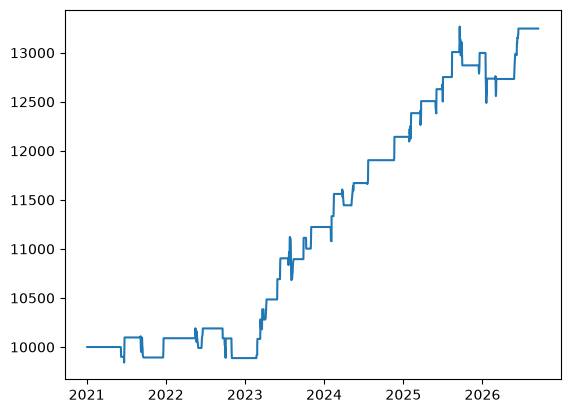

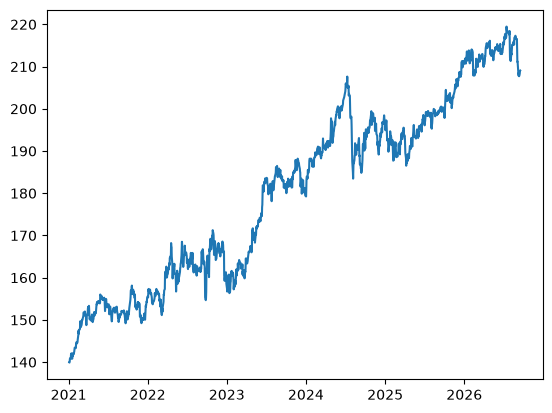

In [22]:
current_date = None
daily_list = []
daily_equity_list = []
for index in range(len(stats._equity_curve)):
    row = stats._equity_curve.iloc[index]
    if current_date is None:
        current_date = row.name
        first_hour = row.Equity
    else:
        if current_date.date() != row.name.date():
            daily_list.append(current_date)
            daily_equity_list.append(stats._equity_curve.iloc[index-1].Equity)
            current_date = None

print(len(daily_list))         
print(len(daily_equity_list)) 

plt.figure(1)
plt.plot(daily_list, daily_equity_list)

df_d1_price = df_d1_raw.loc['2021-1-1' : '2026-9-16']
plt.figure(2)
plt.plot(df_d1_price.index, df_d1_price['Close'])